In [1]:
import pandas as pd
data = pd.read_csv(r"C:\Users\User\Downloads\DATA ANALYSIS PORTFOLIO\5 WATER PROJECTS\PIPE FAILURE PREDICTION\04_pipe_failure_prediction.csv")

In [2]:
data.head()

,pipe_id,diameter_mm,material,installation_year,age_years,length_m,operating_pressure_m,soil_type,elevation_m,previous_failures,leakage_incidents,annual_rainfall_mm,recent_rainfall_mm,maintenance_count_24m,failure_within_90_days,failure_risk_score,risk_category
0,P-00001,63,PVC,2016,10,1328.6,39.0,Clay,1478.0,0,3,672.4,0.6,4,1,12.7,Low
1,P-00002,50,GI,2011,15,690.1,11.1,Rocky,1768.3,0,1,956.3,6.9,3,0,8.1,Low
2,P-00003,63,HDPE,2013,13,2073.1,34.2,Sandy,809.2,1,1,1331.9,7.6,3,0,14.4,Low
3,P-00004,160,PVC,2012,14,1867.8,44.8,Clay,948.3,2,1,1323.1,8.7,3,0,24.2,Low
4,P-00005,40,PVC,2022,4,2119.9,31.8,Black Cotton,1012.5,0,0,882.4,3.2,2,0,7.5,Low


In [3]:
# SEPARATE NUMERICAL AND CATEGORICAL VARIABLES
numerical_columns = data.select_dtypes(include=['int64','float64']).columns
numerical_columns

Index(['diameter_mm', 'installation_year', 'age_years', 'length_m',
       'operating_pressure_m', 'elevation_m', 'previous_failures',
       'leakage_incidents', 'annual_rainfall_mm', 'recent_rainfall_mm',
       'maintenance_count_24m', 'failure_within_90_days',
       'failure_risk_score'],
      dtype='object')

In [4]:
categorical_columns = data.select_dtypes(include=['object']).columns
categorical_columns

Index(['pipe_id', 'material', 'soil_type', 'risk_category'], dtype='object')

In [5]:
# BIVARIATE ANALYSIS 'diameter_mm' and 'failure_within_90_days'
# which diameter has the highest failure probability
data['diameter_mm'].value_counts() # pipe diameters in the dataset


diameter_mm
63     717
32     701
40     691
50     686
90     657
75     652
160    649
25     640
110    607
Name: count, dtype: int64

In [6]:
pipe_diameter_failure_probability = data.groupby('diameter_mm')['failure_within_90_days'].agg(
    ['count','sum','mean']).sort_values('mean', ascending = False)
pipe_diameter_failure_probability

,count,sum,mean
diameter_mm,,,
40,691,188,0.272069
63,717,193,0.269177
32,701,188,0.268188
25,640,171,0.267188
50,686,183,0.266764
160,649,167,0.257319
75,652,167,0.256135
90,657,165,0.251142
110,607,152,0.250412


In [7]:
# pipe diameter failure rate
pipe_diameter_failure_probability = (
    data.groupby('diameter_mm')['failure_within_90_days'].agg(
        ['count','sum','mean']).sort_values('mean', ascending = False))

pipe_diameter_failure_probability['failure_rate_%'] = pipe_diameter_failure_probability['mean'] * 100
pipe_diameter_failure_probability.sort_values('failure_rate_%', ascending=False)

,count,sum,mean,failure_rate_%
diameter_mm,,,,
40,691,188,0.272069,27.206946
63,717,193,0.269177,26.917713
32,701,188,0.268188,26.818830
25,640,171,0.267188,26.718750
50,686,183,0.266764,26.676385
160,649,167,0.257319,25.731895
75,652,167,0.256135,25.613497
90,657,165,0.251142,25.114155
110,607,152,0.250412,25.041186


In [8]:
# BIVARIATE ANALYSIS 'installation_year' and 'failure_within_90_days'
# which installation_year has the highest failure probability and rate
data['installation_year'].value_counts() # installation years in the dataset

pipe_installation_year_failure_probability = (
    data.groupby('installation_year')['failure_within_90_days'].agg(
        ['count','sum','mean']).sort_values('mean', ascending = False))

pipe_installation_year_failure_probability['failure_rate_%']= pipe_installation_year_failure_probability['mean'] * 100
pipe_installation_year_failure_probability.sort_values('failure_rate_%', ascending=False)

pipe_installation_year_failure_probability.head(6)

,count,sum,mean,failure_rate_%
installation_year,,,,
1996,195,105,0.538462,53.846154
1997,195,105,0.538462,53.846154
1995,182,94,0.516484,51.648352
1999,177,84,0.474576,47.457627
1998,206,95,0.461165,46.116505
2000,200,90,0.450000,45.000000


In [9]:
pipe_installation_year_failure_probability.tail(6)

,count,sum,mean,failure_rate_%
installation_year,,,,
2019,204,24,0.117647,11.764706
2017,207,23,0.111111,11.111111
2020,202,19,0.094059,9.405941
2021,207,15,0.072464,7.246377
2023,191,13,0.068063,6.806283
2024,200,12,0.060000,6.000000


In [10]:
# BIVARIATE ANALYSIS 'age_year' and 'failure_within_90_days'
# which age_year has the highest failure probability and rate
data['age_years'].value_counts() # age years in the dataset

pipe_age_year_failure_probability = (
    data.groupby('age_years')['failure_within_90_days'].agg(
        ['count','sum','mean']).sort_values('mean', ascending = False))

pipe_age_year_failure_probability['failure_rate_%']= pipe_age_year_failure_probability['mean'] * 100
pipe_age_year_failure_probability.sort_values('failure_rate_%', ascending=False)

pipe_age_year_failure_probability.head(6)

,count,sum,mean,failure_rate_%
age_years,,,,
30,195,105,0.538462,53.846154
29,195,105,0.538462,53.846154
31,182,94,0.516484,51.648352
27,177,84,0.474576,47.457627
28,206,95,0.461165,46.116505
26,200,90,0.450000,45.000000


In [11]:
pipe_age_year_failure_probability.tail(6)

,count,sum,mean,failure_rate_%
age_years,,,,
7,204,24,0.117647,11.764706
9,207,23,0.111111,11.111111
6,202,19,0.094059,9.405941
5,207,15,0.072464,7.246377
3,191,13,0.068063,6.806283
2,200,12,0.060000,6.000000


In [12]:
data['age_years'].value_counts()

age_years
19    243
4     221
18    218
21    215
8     213
13    208
15    207
5     207
9     207
28    206
7     204
14    203
6     202
24    200
2     200
26    200
16    199
23    198
22    196
29    195
30    195
10    194
3     191
20    188
25    186
17    185
31    182
12    181
11    179
27    177
Name: count, dtype: int64

In [13]:
# BIVARIATE ANALYSIS 'length_m' and 'failure_within_90_days'
# which age_year has the highest failure probability and rate
data['length_m'].value_counts() # age years in the dataset

pipe_length_failure_probability = (
    data.groupby('length_m')['failure_within_90_days'].agg(
        ['count','sum','mean']).sort_values('mean', ascending = False))

pipe_length_failure_probability['failure_rate_%']=pipe_length_failure_probability['mean']*100
pipe_length_failure_probability.sort_values('failure_rate_%', ascending=False)

pipe_length_failure_probability.head(15)

,count,sum,mean,failure_rate_%
length_m,,,,
1496.4,1,1,1.0,100.0
621.3,1,1,1.0,100.0
2106.7,1,1,1.0,100.0
617.2,1,1,1.0,100.0
616.0,1,1,1.0,100.0
615.6,1,1,1.0,100.0
615.3,1,1,1.0,100.0
614.2,1,1,1.0,100.0
2109.5,1,1,1.0,100.0


In [14]:
pipe_length_failure_probability.tail(10)

,count,sum,mean,failure_rate_%
length_m,,,,
1027.4,1,0,0.0,0.0
1028.1,1,0,0.0,0.0
1028.3,1,0,0.0,0.0
1028.9,1,0,0.0,0.0
1030.8,2,0,0.0,0.0
1030.9,1,0,0.0,0.0
1032.2,1,0,0.0,0.0
1032.8,1,0,0.0,0.0
1032.9,1,0,0.0,0.0


In [15]:
# BIVARIATE ANALYSIS 'Operating_pressure_m' and 'failure_within_90_days'
# do pipes with high Operating_pressure_m has the highest failure probability and rate
data['operating_pressure_m'].value_counts() # Operating_pressure_m in the dataset

operating_pressure_failure_probability = (
    data.groupby('operating_pressure_m')['failure_within_90_days'].agg(
        ['count','sum','mean']).sort_values('mean', ascending = False))

operating_pressure_failure_probability['failure_rate_%']=operating_pressure_failure_probability['mean']*100
operating_pressure_failure_probability.sort_values('failure_rate_%', ascending=False)

operating_pressure_failure_probability.head(10)


,count,sum,mean,failure_rate_%
operating_pressure_m,,,,
59.4,1,1,1.0,100.0
63.8,1,1,1.0,100.0
65.8,1,1,1.0,100.0
60.7,1,1,1.0,100.0
55.4,2,2,1.0,100.0
65.2,1,1,1.0,100.0
55.6,2,2,1.0,100.0
64.6,1,1,1.0,100.0
64.4,2,2,1.0,100.0


In [16]:
operating_pressure_failure_probability.tail(10)

,count,sum,mean,failure_rate_%
operating_pressure_m,,,,
60.6,1,0,0.0,0.0
14.0,3,0,0.0,0.0
59.9,3,0,0.0,0.0
25.4,14,0,0.0,0.0
14.8,2,0,0.0,0.0
59.5,2,0,0.0,0.0
14.9,2,0,0.0,0.0
59.3,1,0,0.0,0.0
59.2,1,0,0.0,0.0


In [17]:
data['operating_pressure_m'].max() # maximum operating pressure

75.0

In [18]:
data['operating_pressure_m'].min()# minimum operating pressure

8.0

In [19]:
data['operating_pressure_m'].value_counts()

operating_pressure_m
8.0     81
35.4    33
31.9    32
30.6    31
42.2    28
        ..
59.1     1
13.9     1
57.5     1
61.1     1
72.6     1
Name: count, Length: 586, dtype: int64

In [20]:
# BIVARIATE ANALYSIS 'leakage_incidents' and 'failure_within_90_days'
# do pipes with high leakage incidents have the highest failure probability and rate
data['leakage_incidents'].value_counts() # leakage incidents in the dataset

leakage_incidents_failure_probability = (
    data.groupby('leakage_incidents')['failure_within_90_days'].agg(
        ['count','sum','mean']).sort_values('mean', ascending = False))

leakage_incidents_failure_probability['failure_rate_%']=leakage_incidents_failure_probability['mean']*100
leakage_incidents_failure_probability.sort_values('failure_rate_%', ascending=False)

leakage_incidents_failure_probability

,count,sum,mean,failure_rate_%
leakage_incidents,,,,
9,2,2,1.000000,100.000000
6,92,48,0.521739,52.173913
8,10,5,0.500000,50.000000
7,29,14,0.482759,48.275862
5,204,90,0.441176,44.117647
4,369,162,0.439024,43.902439
3,799,295,0.369212,36.921151
2,1191,372,0.312343,31.234257
1,1636,347,0.212103,21.210269


In [21]:
data['leakage_incidents'].value_counts()

leakage_incidents
0    1668
1    1636
2    1191
3     799
4     369
5     204
6      92
7      29
8      10
9       2
Name: count, dtype: int64

In [22]:
# BIVARIATE ANALYSIS 'annual_rainfall_mm' and 'failure_within_90_days'
# do pipes with high annual_rainfall_mm have the highest failure probability and rate
data['annual_rainfall_mm'].value_counts() # annual_rainfall_mm in the dataset

annual_rainfall_failure_probability = (
    data.groupby(['diameter_mm','annual_rainfall_mm'])['failure_within_90_days'].agg(
    ['count','sum','mean']).sort_values('mean', ascending = False))

annual_rainfall_failure_probability['failure_rate_%']=annual_rainfall_failure_probability['mean']*100
annual_rainfall_failure_probability.sort_values('failure_rate_%', ascending=False)

annual_rainfall_failure_probability.head(10)

count  sum  mean  failure_rate_%
diameter_mm annual_rainfall_mm                                  
63          991.9                   1    1   1.0           100.0
            1043.6                  1    1   1.0           100.0
32          1116.1                  1    1   1.0           100.0
63          1016.3                  1    1   1.0           100.0
            1018.3                  1    1   1.0           100.0
            1021.3                  1    1   1.0           100.0
            1022.3                  1    1   1.0           100.0
            1024.7                  1    1   1.0           100.0
            1026.7                  1    1   1.0           100.0
            1036.5                  1    1   1.0           100.0

In [23]:
annual_rainfall_failure_probability.tail(10)

count  sum  mean  failure_rate_%
diameter_mm annual_rainfall_mm                                  
32          1104.7                  1    0   0.0             0.0
63          1048.0                  1    0   0.0             0.0
32          1103.9                  1    0   0.0             0.0
63          1049.4                  1    0   0.0             0.0
            1049.9                  1    0   0.0             0.0
            1050.9                  1    0   0.0             0.0
            1051.9                  1    0   0.0             0.0
32          1103.1                  1    0   0.0             0.0
            1103.0                  1    0   0.0             0.0
160         1800.0                  2    0   0.0             0.0

In [24]:
# BIVARIATE ANALYSIS 'recent_rainfall_mm' and 'failure_within_90_days'
# do pipes with high recent_rainfall_mm have the highest failure probability and rate
data['recent_rainfall_mm'].value_counts() # recent_rainfall_mm in the dataset

recent_rainfall_failure_probability = (
    data.groupby('recent_rainfall_mm')['failure_within_90_days'].agg(
    ['count','sum','mean']).sort_values('mean', ascending = False))

recent_rainfall_failure_probability['failure_rate_%']=recent_rainfall_failure_probability['mean']*100
recent_rainfall_failure_probability.sort_values('failure_rate_%', ascending=False)

recent_rainfall_failure_probability.head(10)

,count,sum,mean,failure_rate_%
recent_rainfall_mm,,,,
32.3,1,1,1.0,100.0
20.2,1,1,1.0,100.0
14.8,2,2,1.0,100.0
16.8,2,2,1.0,100.0
18.1,1,1,1.0,100.0
18.8,1,1,1.0,100.0
19.8,1,1,1.0,100.0
20.1,1,1,1.0,100.0
18.2,1,1,1.0,100.0


In [25]:
recent_rainfall_failure_probability.tail(10)

,count,sum,mean,failure_rate_%
recent_rainfall_mm,,,,
13.8,5,0,0.0,0.0
16.9,1,0,0.0,0.0
18.6,1,0,0.0,0.0
15.7,2,0,0.0,0.0
13.1,3,0,0.0,0.0
19.0,1,0,0.0,0.0
19.1,1,0,0.0,0.0
19.3,1,0,0.0,0.0
19.4,1,0,0.0,0.0


In [26]:
# BIVARIATE ANALYSIS 'material' and 'failure_within_90_days'
# do pipe material have the highest failure probability and rate
data['material'].value_counts() # material in the dataset

material_failure_probability = (
    data.groupby('material')['failure_within_90_days'].agg(
    ['count','sum','mean']).sort_values('mean', ascending = False))

material_failure_probability

,count,sum,mean
material,,,
Ductile Iron,855,240,0.280702
GI,1222,340,0.278232
HDPE,1203,325,0.270158
PVC,2720,669,0.245956


In [27]:
# BIVARIATE ANALYSIS 'soil_type' and 'failure_within_90_days'
# does soil type have the highest failure probability and rate
data['soil_type'].value_counts() # soil_type in the dataset

soil_type_failure_probability = (
    data.groupby('soil_type')['failure_within_90_days'].agg(
    ['count','sum','mean']).sort_values('mean', ascending = False))

soil_type_failure_probability['failure_rate_%']= soil_type_failure_probability['mean']*100
soil_type_failure_probability.sort_values('failure_rate_%', ascending=False)

soil_type_failure_probability.head(10)

,count,sum,mean,failure_rate_%
soil_type,,,,
Black Cotton,588,218,0.370748,37.074830
Clay,1676,450,0.268496,26.849642
Sandy,1226,309,0.252039,25.203915
Loam,1780,435,0.244382,24.438202
Rocky,730,162,0.221918,22.191781


In [28]:
# BIVARIATE ANALYSIS 'previous_failures' and 'failure_within_90_days'
# does previous_failures have the highest failure probability and rate
data['previous_failures'].value_counts() # previous_failures in the dataset

previous_failures_probability = (
    data.groupby('previous_failures')['failure_within_90_days'].agg(
    ['count','sum','mean']).sort_values('mean', ascending = False))

previous_failures_probability['failure_rate_%']= previous_failures_probability['mean']*100
previous_failures_probability.sort_values('failure_rate_%', ascending=False)

previous_failures_probability

,count,sum,mean,failure_rate_%
previous_failures,,,,
8,41,29,0.707317,70.731707
7,51,33,0.647059,64.705882
9,8,5,0.625000,62.500000
6,168,93,0.553571,55.357143
5,314,154,0.490446,49.044586
10,7,3,0.428571,42.857143
4,582,237,0.407216,40.721649
3,893,277,0.310190,31.019037
2,1218,308,0.252874,25.287356


In [29]:
# BIVARIATE ANALYSIS 'maintenance_count_24m' and 'failure_within_90_days'
# does maintenance_count_24m have the highest failure probability and rate
data['maintenance_count_24m'].value_counts() # maintenance_count_24m in the dataset

maintenance_failures_probability = (
    data.groupby('maintenance_count_24m')['failure_within_90_days'].agg(
    ['count','sum','mean']).sort_values('mean', ascending = False))

maintenance_failures_probability['failure_rate_%']= maintenance_failures_probability['mean']*100
maintenance_failures_probability.sort_values('failure_rate_%', ascending=False)

maintenance_failures_probability

,count,sum,mean,failure_rate_%
maintenance_count_24m,,,,
10,66,29,0.439394,43.939394
6,425,176,0.414118,41.411765
8,189,78,0.412698,41.269841
7,286,115,0.402098,40.209790
11,21,8,0.380952,38.095238
4,763,256,0.335518,33.551769
5,594,199,0.335017,33.501684
3,872,222,0.254587,25.458716
9,90,20,0.222222,22.222222


In [30]:
# select the best variables that will be used by the model to make predictions
# by excluding variables that might cause data leakage and overlapping

model_features = [
    'diameter_mm',
    'material',
    'age_years',
    'length_m',
    'operating_pressure_m',
    'soil_type',
    'elevation_m',
    'previous_failures',
    'leakage_incidents',
    'annual_rainfall_mm',
    'recent_rainfall_mm',
    'maintenance_count_24m'
]


In [31]:
# DEFINE YOUR X AND Y
x = data[model_features]

In [32]:
y = data['failure_within_90_days']

In [33]:
print(x.shape) # the x features have 6000 rows and 12 variables
print(y.shape) # the y target has 6000 rows and 1 variable

(6000, 12)
(6000,)


In [34]:
x.columns.to_list() # the 12 x features 

['diameter_mm',
 'material',
 'age_years',
 'length_m',
 'operating_pressure_m',
 'soil_type',
 'elevation_m',
 'previous_failures',
 'leakage_incidents',
 'annual_rainfall_mm',
 'recent_rainfall_mm',
 'maintenance_count_24m']

In [35]:
# SPLIT THE MODEL FEATURES INTO TRAINING AND TESTING SETS
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [36]:
print('Training set:', x_train.shape)
print('Testing set:', x_test.shape)

Training set: (4800, 12)
Testing set: (1200, 12)


In [37]:
# WE NEED TO SCALE/STANDARDIZE THE NUMERICAL VARIABLES
# identify numerical variables 
numerical_variables = x.select_dtypes(include=['int64','float64']).columns
numerical_variables

Index(['diameter_mm', 'age_years', 'length_m', 'operating_pressure_m',
       'elevation_m', 'previous_failures', 'leakage_incidents',
       'annual_rainfall_mm', 'recent_rainfall_mm', 'maintenance_count_24m'],
      dtype='object')

In [38]:
# scale/standardize
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train[numerical_variables])

In [39]:
x_test_scaled = scaler.transform(x_test[numerical_variables])

In [40]:
# ENCODE THE CATEGORICAL VARIABLES
from sklearn.preprocessing import OneHotEncoder
categorical_features = x.select_dtypes(include='object').columns
categorical_features

Index(['material', 'soil_type'], dtype='object')

In [41]:
# CREATE THE ENCODER
encoder = OneHotEncoder(handle_unknown='ignore')

In [42]:
#ENCODE THE CATEGORICAL TESTING AND TESTING DATA
x_train_enc = encoder.fit_transform(x_train[categorical_features])

In [43]:
x_test_enc = encoder.transform(x_test[categorical_features])

In [44]:
#COMBINE THE SCALED AND ENCODED DATASETS
from scipy.sparse import hstack
x_train_processed = hstack([
    x_train_scaled,
    x_train_enc
])

x_test_processed = hstack([
    x_test_scaled,
    x_test_enc
])


In [45]:
#IMPORT LOGISTIC REGRESSION
from sklearn.linear_model import LogisticRegression

In [46]:
#CREATE THE MODEL
log_reg = LogisticRegression(random_state=42)

In [47]:
#TRAIN THE MODEL
log_reg.fit(x_train_processed, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [48]:
#MAKE PREDICTIONS
y_pred_log = log_reg.predict(x_test_processed)

In [49]:
# EVALUATE THE MODEL
#CALCULATE ACCURACY
from sklearn.metrics import accuracy_score
log_accuracy = accuracy_score(y_test, y_pred_log)
print(f"Logistic Regression Accuracy: {log_accuracy:.4f}")

Logistic Regression Accuracy: 0.7658


In [50]:
#CLASSIFICATION REPORT
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_log))

              precision    recall  f1-score   support

           0       0.78      0.94      0.86       885
           1       0.62      0.27      0.38       315

    accuracy                           0.77      1200
   macro avg       0.70      0.61      0.62      1200
weighted avg       0.74      0.77      0.73      1200



In [51]:
#CONFUSION MATRIX
from sklearn.metrics import confusion_matrix
log_cm = confusion_matrix(y_test, y_pred_log)
print(log_cm)

[[833  52]
 [229  86]]


In [55]:
# ROC-AUC SCORE
from sklearn.metrics import roc_auc_score
y_prob_log = log_reg.predict_proba(x_test_processed)[:, 1]
roc_auc_log = roc_auc_score(y_test, y_prob_log)
print(f"Logistic Regression ROC-AUC: {roc_auc_log:.4f}")

Logistic Regression ROC-AUC: 0.7605


In [57]:
# TEST SEVERAL THRESHOLDS
import pandas as pd
from sklearn.metrics import precision_score, recall_score, f1_score
thresholds = [0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80]

threshold_results = []

for threshold in thresholds:
    y_pred_threshold = (y_prob_log >= threshold).astype(int)

    threshold_results.append({
    'threshold': threshold,
    'precision': precision_score(y_test, y_pred_threshold),
    'recall': recall_score(y_test, y_pred_threshold),
    'f1_score': f1_score(y_test, y_pred_threshold)
    })

threshold_df = pd.DataFrame(threshold_results)
threshold_df

,threshold,precision,recall,f1_score
0,0.2,0.398462,0.822222,0.536788
1,0.3,0.469626,0.638095,0.541050
2,0.4,0.541176,0.438095,0.484211
3,0.5,0.623188,0.273016,0.379691
4,0.6,0.754386,0.136508,0.231183
5,0.7,0.894737,0.053968,0.101796
6,0.8,0.500000,0.003175,0.006309


In [59]:
# FIND THE THRESHOLD WITH THE HIGHEST F1
best_threshold = threshold_df.loc[
    threshold_df['f1_score'].idxmax()
    ]
best_threshold

threshold    0.300000
precision    0.469626
recall       0.638095
f1_score     0.541050
Name: 1, dtype: float64

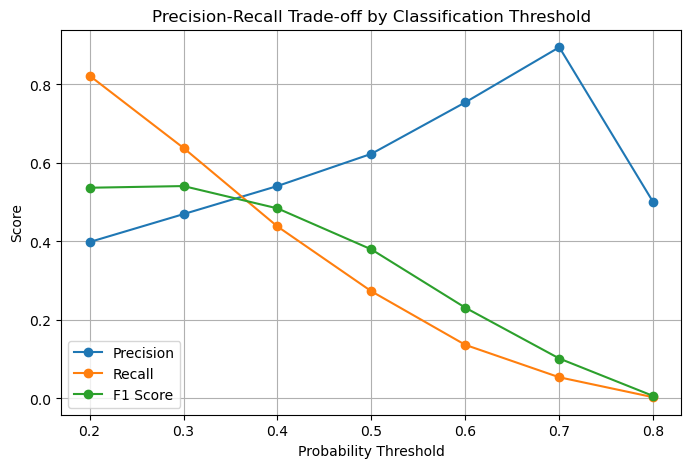

In [60]:
# VISUALIZE THE TRADE-OFF
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 5))

plt.plot(
    threshold_df['threshold'],
    threshold_df['precision'],
    marker='o',
    label='Precision'
)
plt.plot(
    threshold_df['threshold'],
    threshold_df['recall'],
    marker='o',
    label='Recall'
)
plt.plot(
    threshold_df['threshold'],
    threshold_df['f1_score'],
    marker='o',
    label='F1 Score'
)
plt.xlabel('Probability Threshold')
plt.ylabel('Score')
plt.title('Precision-Recall Trade-off by Classification Threshold')
plt.legend()
plt.grid()
plt.show()